In [1]:
# Import
import os, time
import torch
import torch.nn as nn
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import glob
from torch.utils.data import TensorDataset, random_split, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from sklearn.metrics import roc_auc_score, average_precision_score, PrecisionRecallDisplay, RocCurveDisplay
#from resnet import ResNet1d
%matplotlib inline
from flwr.app import MetricRecord
plt.style.available
#'seaborn-v0_8-white', 'whitegrid' -- plt.style.use
plt.style.use('tableau-colorblind10')

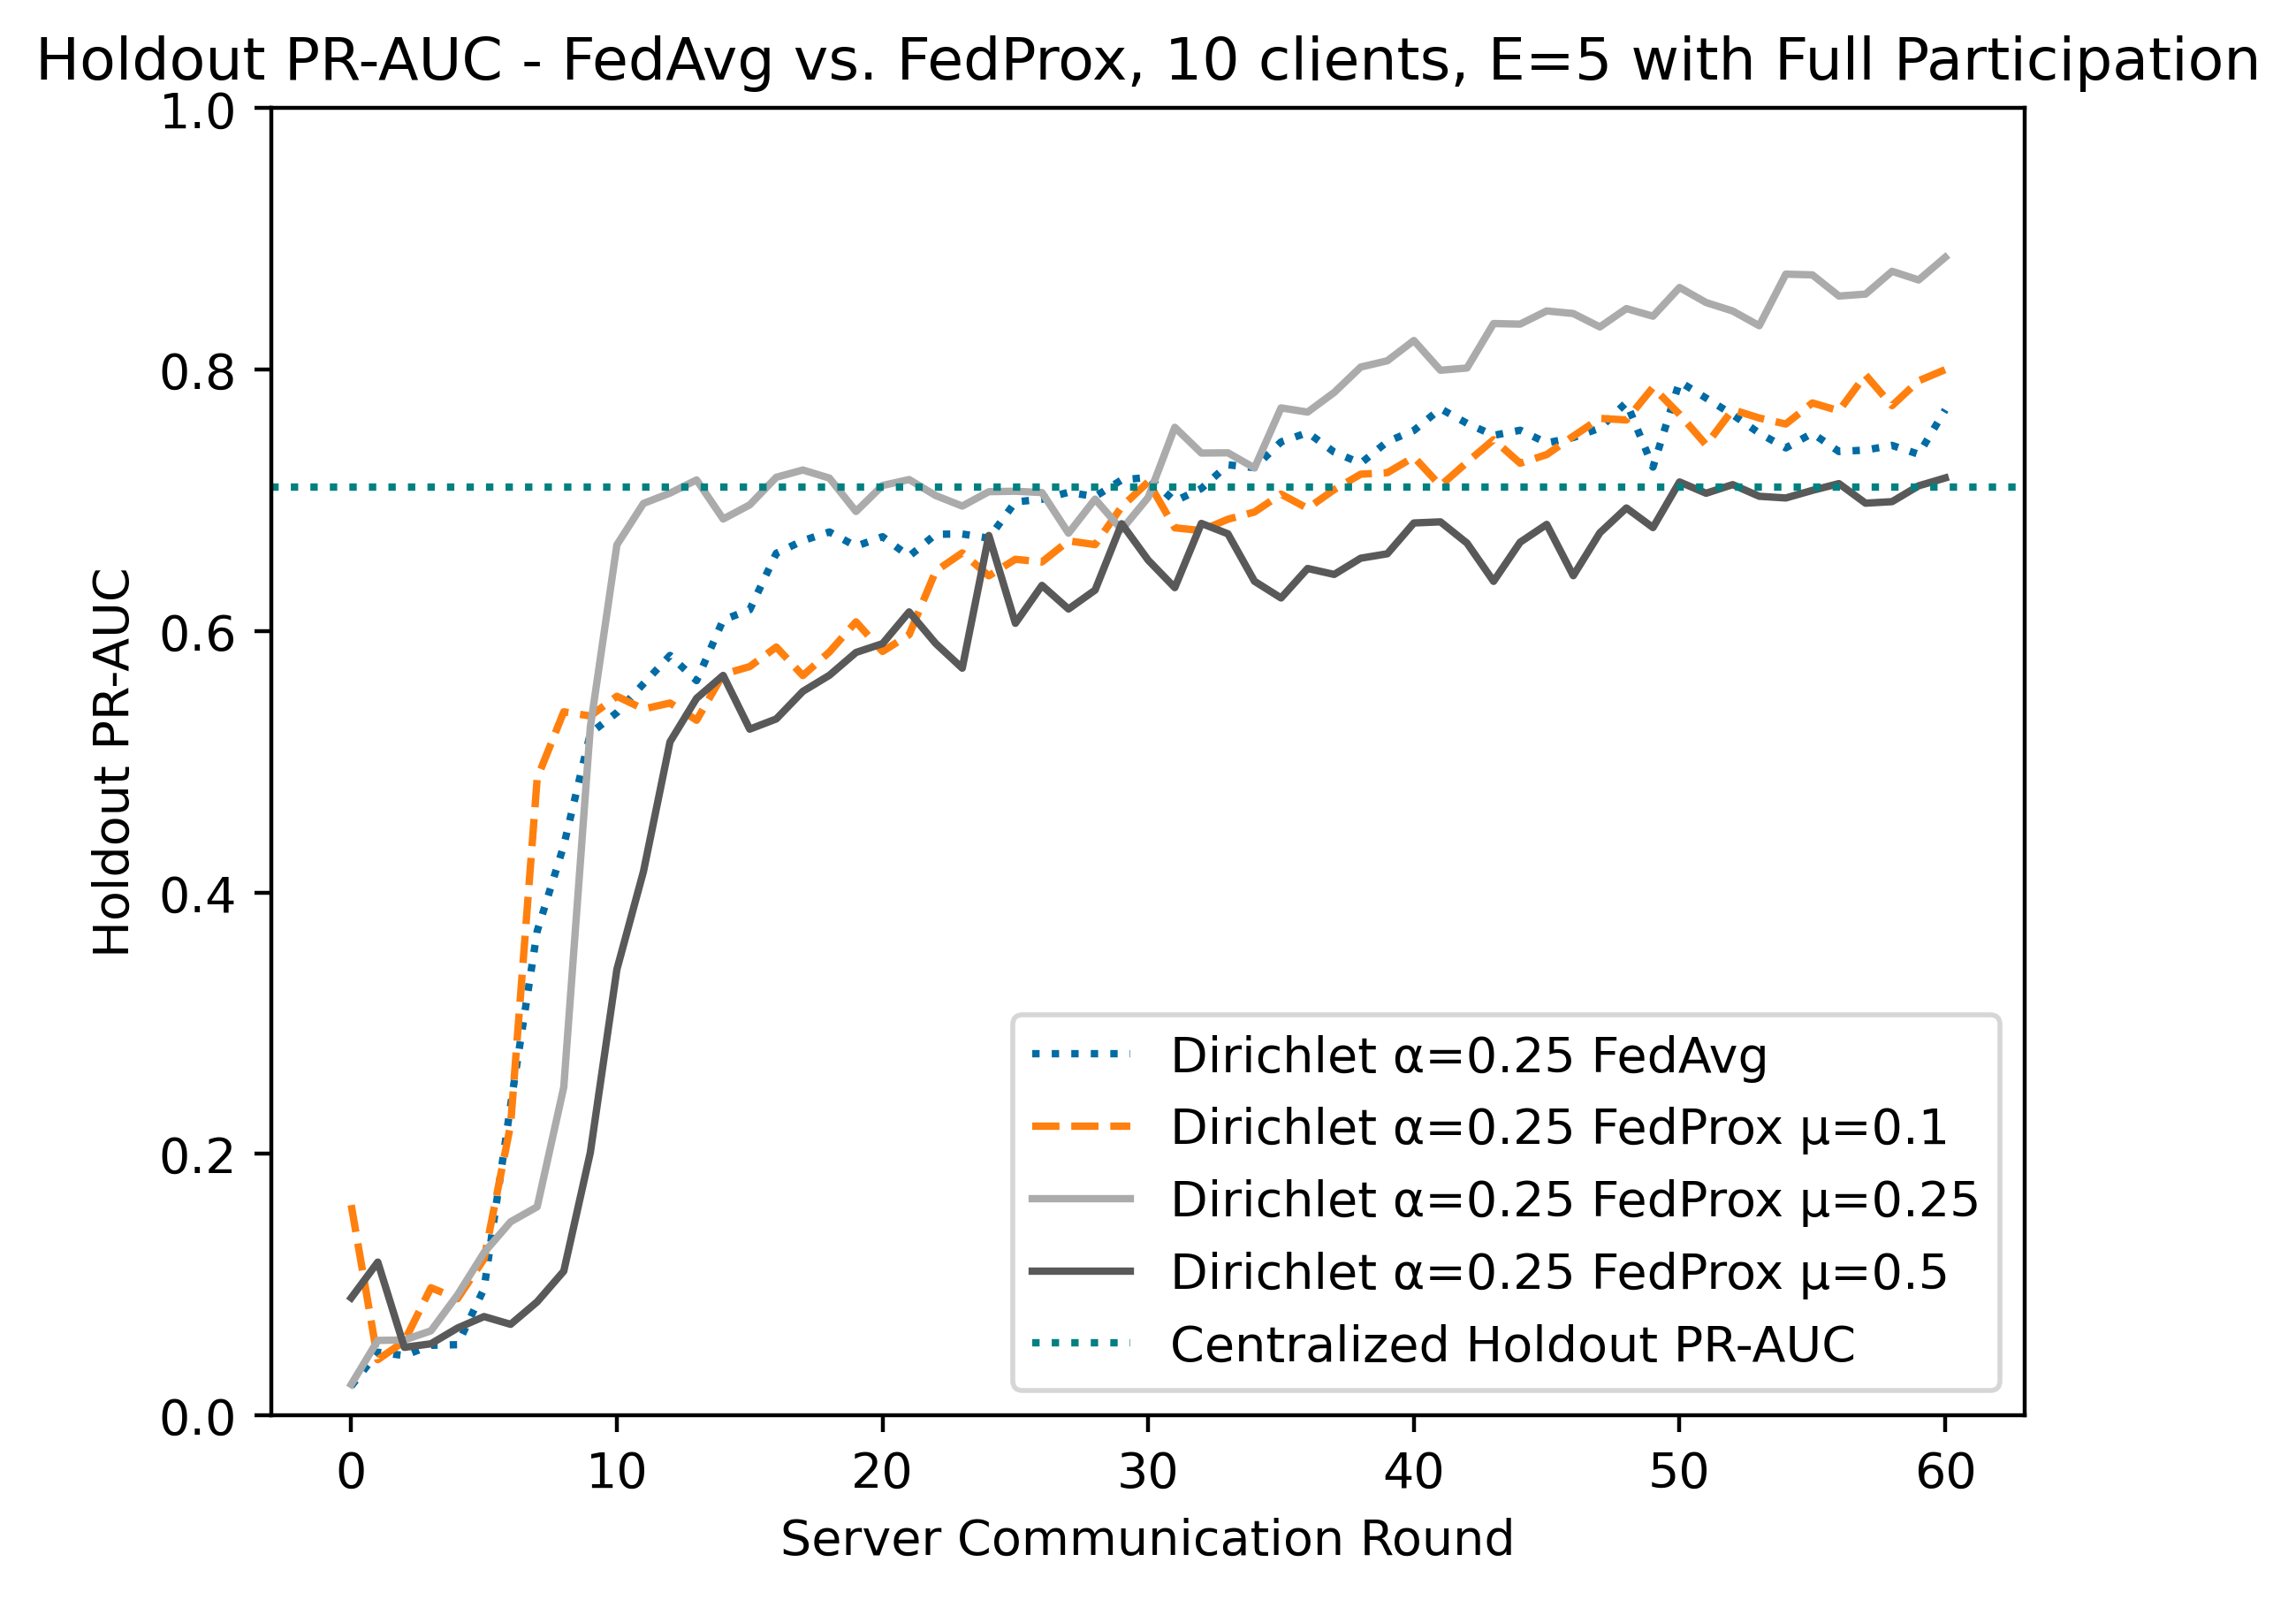

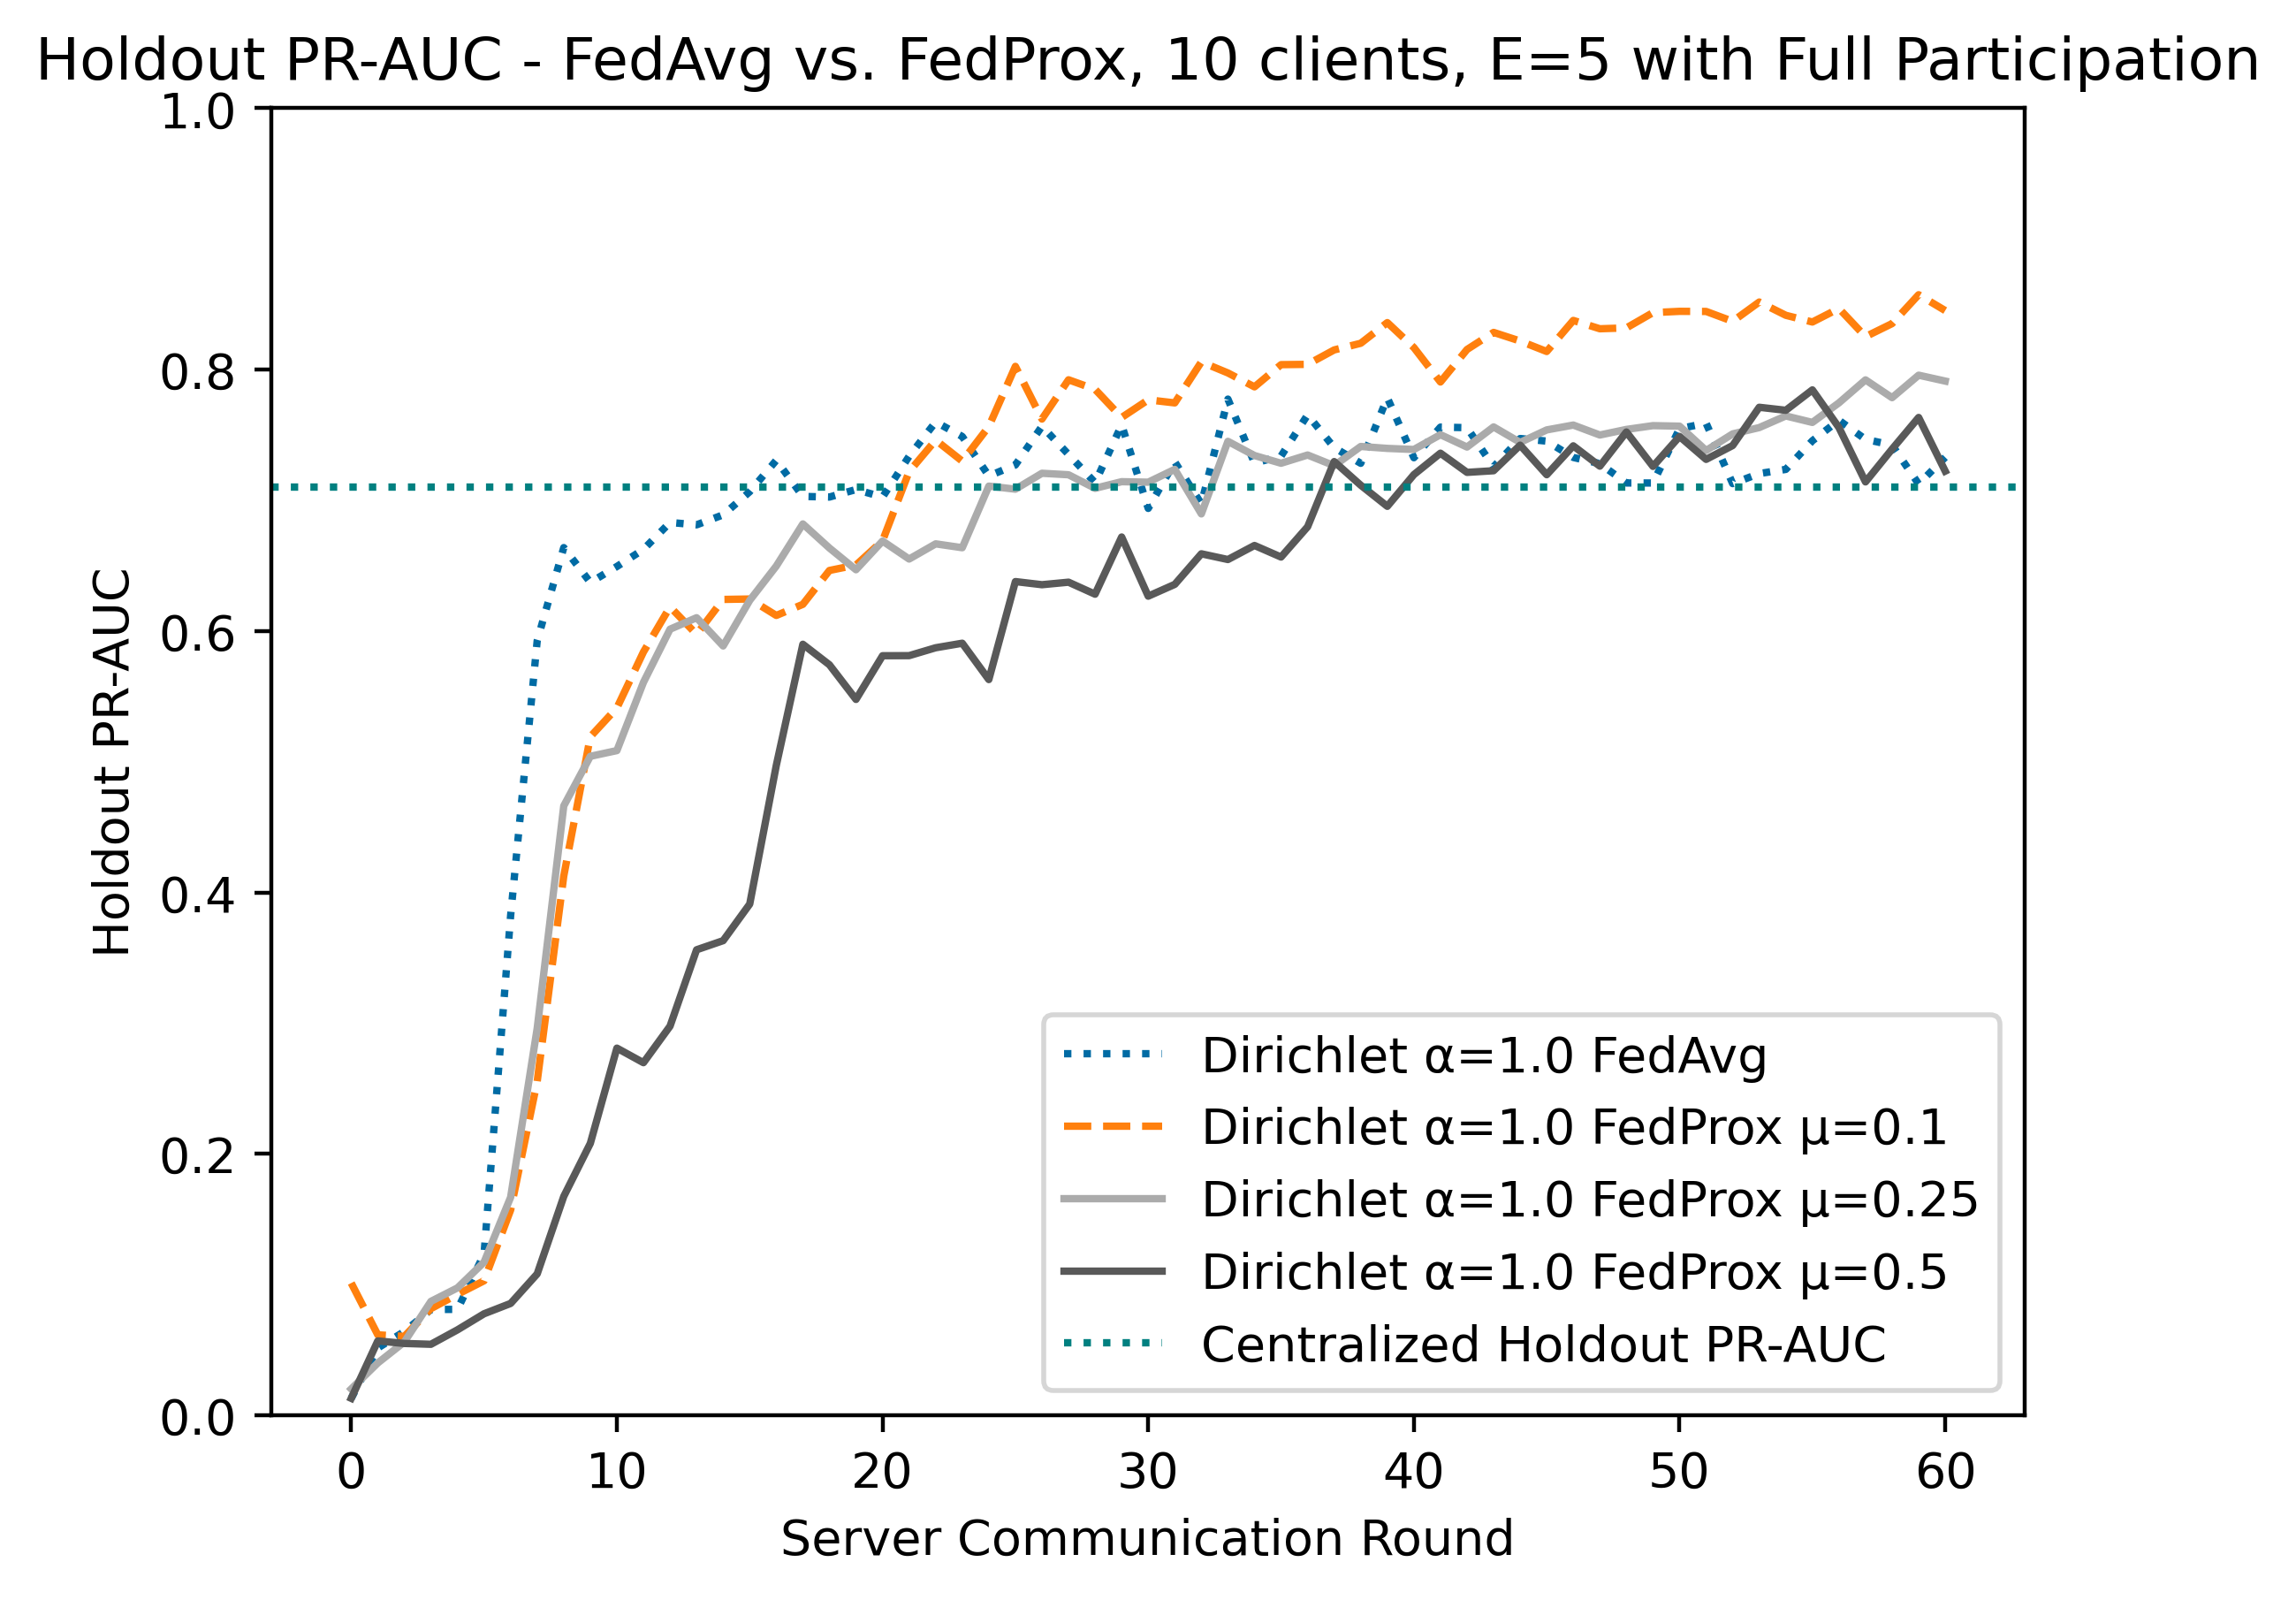

In [2]:
# similarities = [0.25, 1.0]
# for similarity in similarities:
#     plt.figure(dpi=400)
#     jsonObj = pd.read_json(f"fedavg/10cl-lep5/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedAvg", 
#         #marker="*", 
#         linestyle="dotted"
#     )
#     jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.1", 
#         #marker="*", 
#         linestyle="dashed"
#     )
#     jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}-prox0.25/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.25", 
#         #marker="*", 
#         #linestyle="dashed"
#     )
#     jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}-prox0.5/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.5", 
#         #marker="*", 
#         #linestyle="dashed"
#     )
#     plt.ylim(0.0, 5.0)
#     #plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
#     plt.xlabel("Server Communication Round")
#     plt.ylabel("Server Validation Loss")
#     plt.title(f"Server Validation Loss - FedAvg vs. FedProx, 10 clients, E=5 with Full Participation")
#     plt.legend(loc='upper left', frameon=True)
#     #plt.savefig(f"results.png", dpi=400)
#     plt.show()

######################################

similarities = [0.25, 1.0, #2.5, 20
                ]
for similarity in similarities:
    plt.figure(dpi=400)
    jsonObj = pd.read_json(f"fedavg/10cl-lep5/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )
    jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.1", 
        #marker="*", 
        linestyle="dashed"
    )
    jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}-prox0.25/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.25", 
        #marker="*", 
        #linestyle="dashed"
    )
    jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}-prox0.5/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.5", 
        #marker="*", 
        #linestyle="dashed"
    )
    plt.ylim(0.0, 1.0)
    plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Holdout PR-AUC")
    plt.xlabel("Server Communication Round")
    plt.ylabel("Holdout PR-AUC")
    plt.title(f"Holdout PR-AUC - FedAvg vs. FedProx, 10 clients, E=5 with Full Participation")
    plt.legend(frameon=True)
    #plt.savefig(f"results.png", dpi=400)
    plt.show()

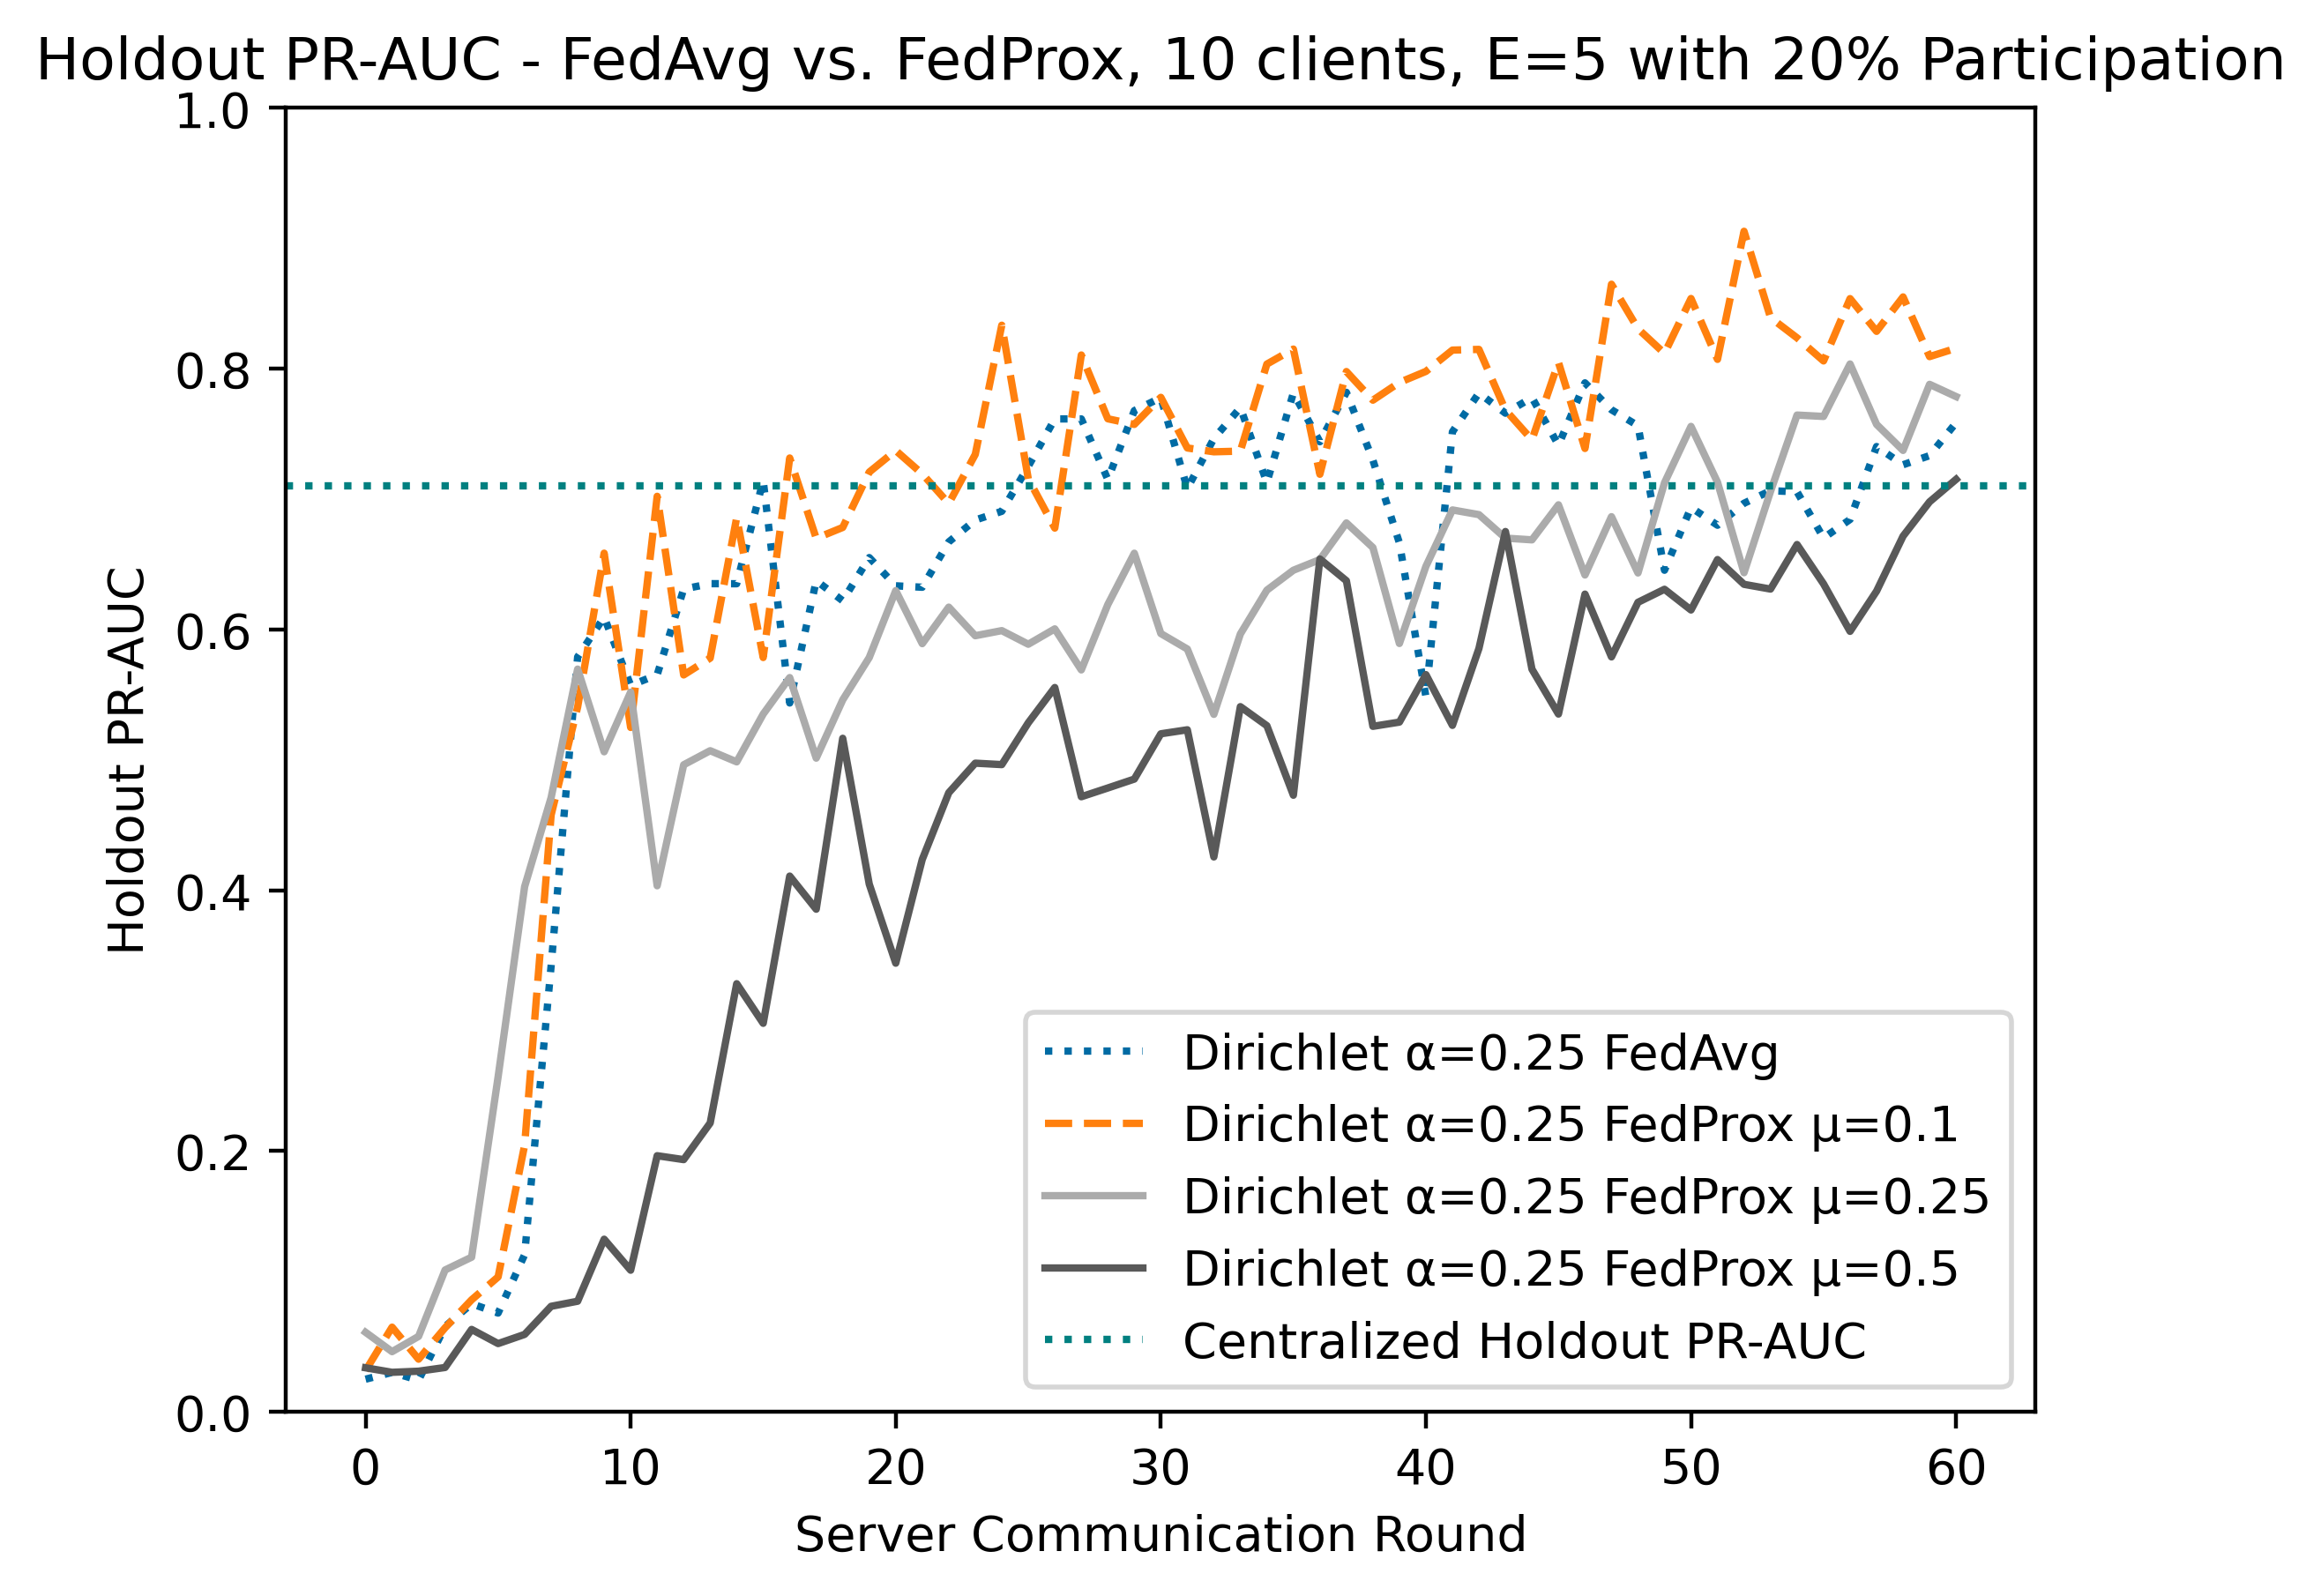

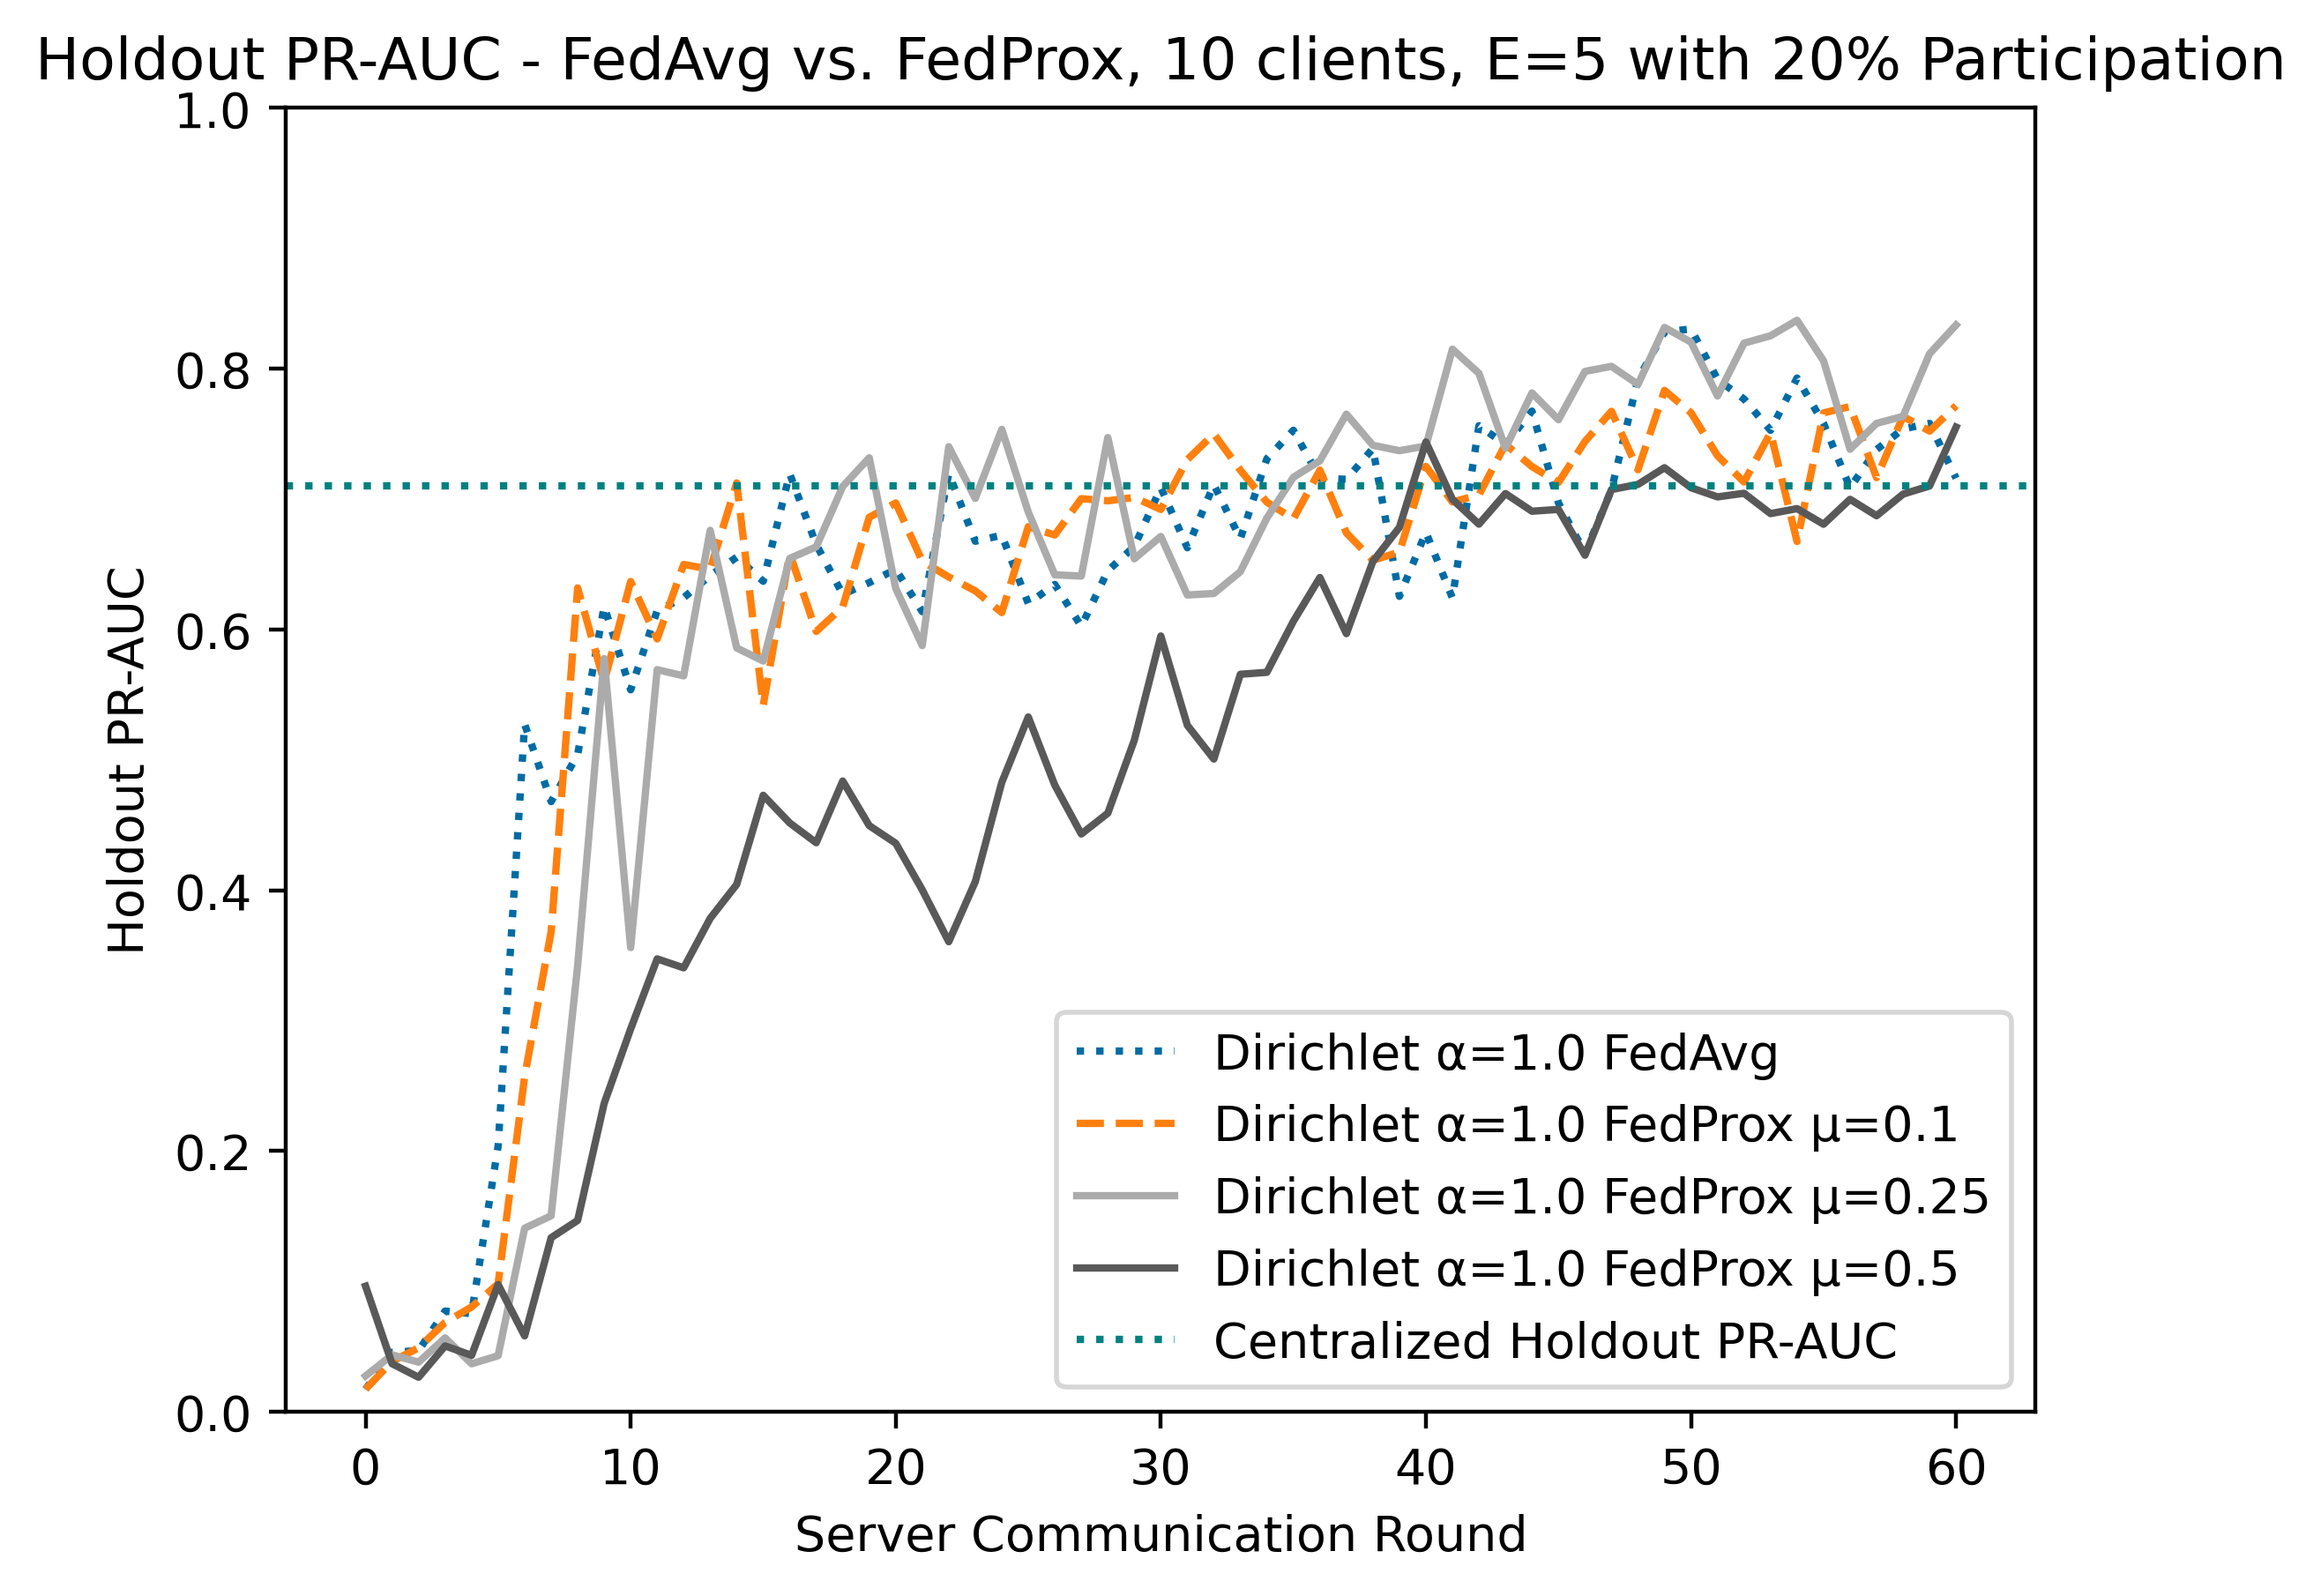

In [3]:
# similarities = [0.25, 1.0]
# for similarity in similarities:
#     plt.figure(dpi=400)
#     jsonObj = pd.read_json(f"fedavg/10cl-lep5-0.2participation/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedAvg", 
#         #marker="*", 
#         linestyle="dotted"
#     )
#     jsonObj = pd.read_json(f"fedprox/10cl-2part/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.1", 
#         #marker="*", 
#         linestyle="dashed"
#     )
#     jsonObj = pd.read_json(f"fedprox/10cl-2part/d{similarity}-prox0.25/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.25", 
#         #marker="*", 
#         #linestyle="dashed"
#     )
#     jsonObj = pd.read_json(f"fedprox/10cl-2part/d{similarity}-prox0.5/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.5", 
#         #marker="*", 
#         #linestyle="dashed"
#     )

#     plt.ylim(0.0, 5.0)
#     #plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
#     plt.xlabel("Server Communication Round")
#     plt.ylabel("Server Validation Loss")
#     plt.title(f"Server Validation Loss - FedAvg vs. FedProx, 10 clients, E=5 with 20% Participation")
#     plt.legend(loc='upper left', frameon=True)
#     #plt.savefig(f"results.png", dpi=400)
#     plt.show()

#############################

similarities = [0.25, 1.0, #2.5, 20
                ]
for similarity in similarities:
    plt.figure(dpi=400)
    jsonObj = pd.read_json(f"fedavg/10cl-lep5-0.2participation/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )
    jsonObj = pd.read_json(f"fedprox/10cl-2part/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.1", 
        #marker="*", 
        linestyle="dashed"
    )
    jsonObj = pd.read_json(f"fedprox/10cl-2part/d{similarity}-prox0.25/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.25", 
        #marker="*", 
        #linestyle="dashed"
    )
    jsonObj = pd.read_json(f"fedprox/10cl-2part/d{similarity}-prox0.5/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.5", 
        #marker="*", 
        #linestyle="dashed"
    )
    plt.ylim(0.0, 1.0)
    plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Holdout PR-AUC")
    plt.xlabel("Server Communication Round")
    plt.ylabel("Holdout PR-AUC")
    plt.title(f"Holdout PR-AUC - FedAvg vs. FedProx, 10 clients, E=5 with 20% Participation")
    plt.legend(frameon=True)
    #plt.savefig(f"results.png", dpi=400)
    plt.show()